# **PaySim Fruad Detection :**

This project builds a robust machine learning pipeline to detect fraudulent mobile money transactions using the PaySim dataset, which simulates real-world financial transaction behavior.

Fraud detection is a critical financial security problem where:

Fraud cases are extremely rare (highly imbalanced dataset)
Missing a fraud (False Negative) leads to direct financial loss
High false positives harm customer experience
Accuracy alone is misleading
This project focuses on cost-sensitive learning, class imbalance handling, and business-driven evaluation metrics.

# **1. Install libraries :**

In [1]:
!pip install xgboost lightgbm imbalanced-learn shap mlflow optuna --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87

pip install:
- install python packages

xgboost :
 - Very powerful for structured/tabular datasets
 - we use this for xgboost model
 - it handles non-linear patterns well
 - we use this when we want high accuracy  ML model.

 lightgbm :
 - used for lightgbm model
 - Similar to XGBoost but faster
 - Very efficient for large dataset
 - Works great on imbalanced classification problems
 - Used for fast training + high performance.

imbalanced-learn :
- Used to handle imbalanced datasets
- This library provides techniques like:
- SMOTE (oversampling fraud cases)
- undersampling
- balanced pipelines
- Used to improve fraud model learning.

shap :
-  Used for model explainability
- explains predictions

mlflow :
- Used for experiment tracking
- When you try multiple models, MLflow helps you store:
- (accuracy, precision, recall, F1 score,model parameters,training versions,saved models)
- Used in industry to manage ML experiments

optuna :
- Used for hyperparameter tuning
- Instead of manually choosing parameters like:
- (learning rate,depth,number of trees)
- Optuna automatically finds best values using optimization.
- Used to improve model performance.

# **2. Mount Google Drive :**

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/ML_PROJECT_M/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/ML_PROJECT_M/plots', exist_ok=True)

print("Drive mounted and folders ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and folders ready.


# **3.  Import all libraries :**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
FRAUD_COLOR  = '#E24B4A'
LEGIT_COLOR  = '#1D9E75'

print("All libraries imported.")

All libraries imported.


# **4. Load the data :**

In [8]:
df=pd.read_csv("/content/drive/MyDrive/ML_PROJECT_M/PS_20174392719_1491204439457_log.csv")

In [9]:
# First 5 rows of the Dataset
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [10]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [11]:
# Dataset Shape (no. of rows and columns)
df.shape

(6362620, 11)

In [12]:
# Columns names
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

# **5. Basic data quality checks :**

In [13]:
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print(f"Duplicates: {df.duplicated().sum()}")

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
df.describe()

MISSING VALUES
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

DUPLICATE ROWS
Duplicates: 0

BASIC STATISTICS


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


- As u can see here there is no missing values and duplicated values so this dataset is cleaned.

# **Column	Meaning:**

1. step -	time step (hour-based simulation)

2. type -	transaction type

3. amount - transaction amount

4. nameOrig - sender account ID

5. oldbalanceOrg - sender balance before transaction

6. newbalanceOrig - sender balance after transaction

7. nameDest - receiver account ID

8. oldbalanceDest -	receiver balance before

9. newbalanceDest	- receiver balance after

10. isFraud -	target column (1 = fraud)

11. isFlaggedFraud - flagged suspicious by system

# **6. Target Column Distribution :**

In [14]:
fraud_counts=df['isFraud'].value_counts()
total_transactions = fraud_counts.sum()
legit_pct = (fraud_counts[0] / total_transactions) * 100
fraud_pct = (fraud_counts[1] / total_transactions) * 100

print("=" * 50)
print("TARGET DISTRIBUTION")
print("=" * 50)
print(f"Legitimate transactions: {fraud_counts[0]:>10,}  ({legit_pct:.2f}%)")
print(f"Fraudulent transactions: {fraud_counts[1]:>10,}  ({fraud_pct:.4f}%)")
print(f"\nImbalance ratio: {fraud_counts[0]/fraud_counts[1]:.0f} : 1")

TARGET DISTRIBUTION
Legitimate transactions:  6,354,407  (99.87%)
Fraudulent transactions:      8,213  (0.1291%)

Imbalance ratio: 774 : 1


- Key insight: 774 legitimate transactions for every 1 fraud.

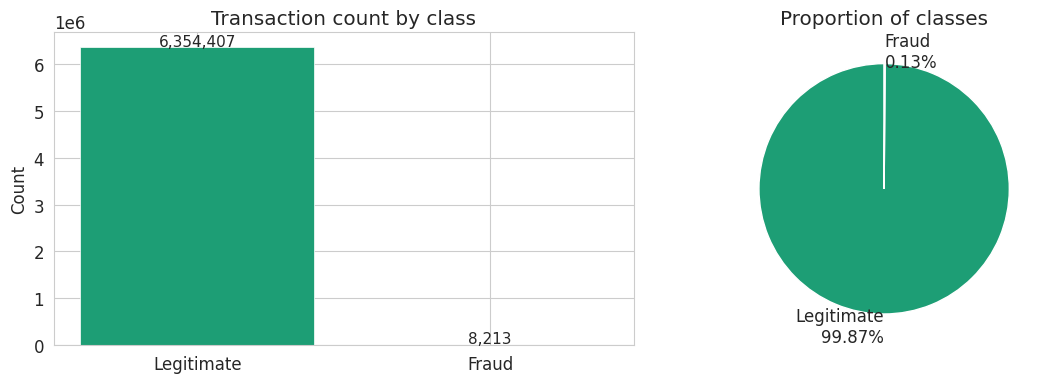

In [15]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values,
            color=[LEGIT_COLOR, FRAUD_COLOR], edgecolor='white', linewidth=0.5)
axes[0].set_title('Transaction count by class')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 30000, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(fraud_counts.values,
            labels=['Legitimate\n99.87%', 'Fraud\n0.13%'],
            colors=[LEGIT_COLOR, FRAUD_COLOR],
            startangle=90, wedgeprops={'edgecolor':'white'})
axes[1].set_title('Proportion of classes')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_PROJECT_M/plots/class_distribution.png', dpi=150)
plt.show()

# **7. Transaction Type Analysis**


In [16]:
print("Transaction type distribution:")
print(df['type'].value_counts())

print("\nFraud by transaction type:")
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'mean', 'count'])
fraud_by_type.columns = ['fraud_count', 'fraud_rate', 'total']
fraud_by_type['fraud_rate_pct'] = fraud_by_type['fraud_rate'] * 100
print(fraud_by_type.sort_values('fraud_count', ascending=False))

Transaction type distribution:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud by transaction type:
          fraud_count  fraud_rate    total  fraud_rate_pct
type                                                      
CASH_OUT         4116    0.001840  2237500        0.183955
TRANSFER         4097    0.007688   532909        0.768799
CASH_IN             0    0.000000  1399284        0.000000
DEBIT               0    0.000000    41432        0.000000
PAYMENT             0    0.000000  2151495        0.000000


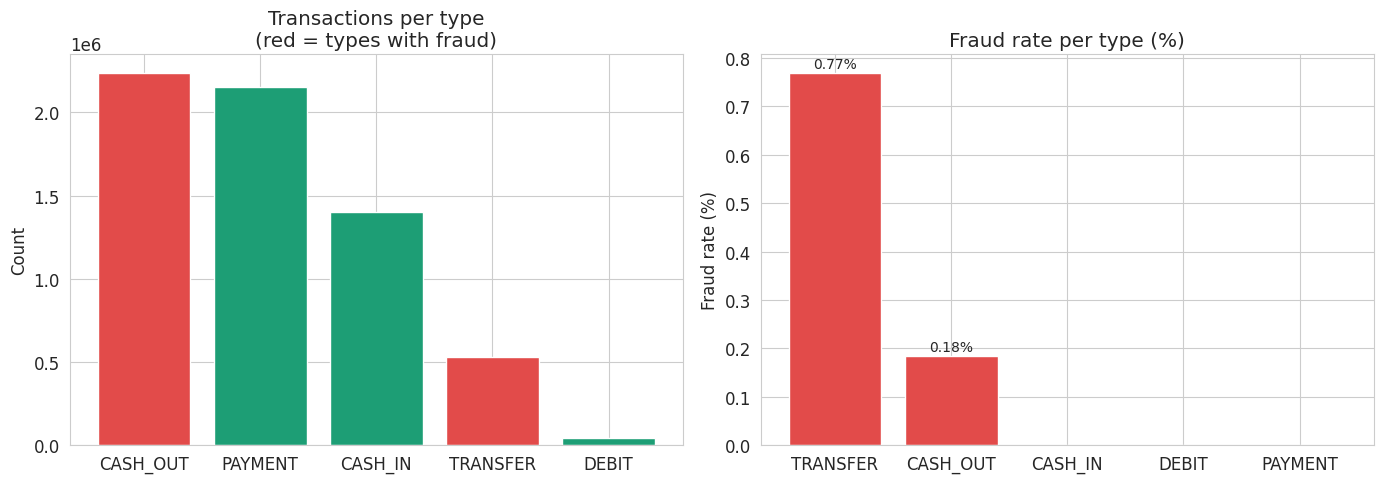

In [17]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count per type
type_counts = df['type'].value_counts()
colors = [FRAUD_COLOR if t in ['TRANSFER','CASH_OUT'] else LEGIT_COLOR
          for t in type_counts.index]
axes[0].bar(type_counts.index, type_counts.values, color=colors)
axes[0].set_title('Transactions per type\n(red = types with fraud)')
axes[0].set_ylabel('Count')

# Fraud rate per type
fraud_rate = df.groupby('type')['isFraud'].mean() * 100
fraud_rate_sorted = fraud_rate.sort_values(ascending=False)
bar_colors = [FRAUD_COLOR if v > 0 else LEGIT_COLOR for v in fraud_rate_sorted.values]
axes[1].bar(fraud_rate_sorted.index, fraud_rate_sorted.values, color=bar_colors)
axes[1].set_title('Fraud rate per type (%)')
axes[1].set_ylabel('Fraud rate (%)')
for i, v in enumerate(fraud_rate_sorted.values):
    if v > 0:
        axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_PROJECT_M/plots/type_analysis.png', dpi=150)
plt.show()

# Key Insight:
- Only TRANSFER (0.77% fraud rate) and CASH_OUT (0.18%) have any fraud.
- PAYMENT, DEBIT, CASH_IN have zero fraud.

# **8. Amount Distribution Fraud vs Non-Fraud**

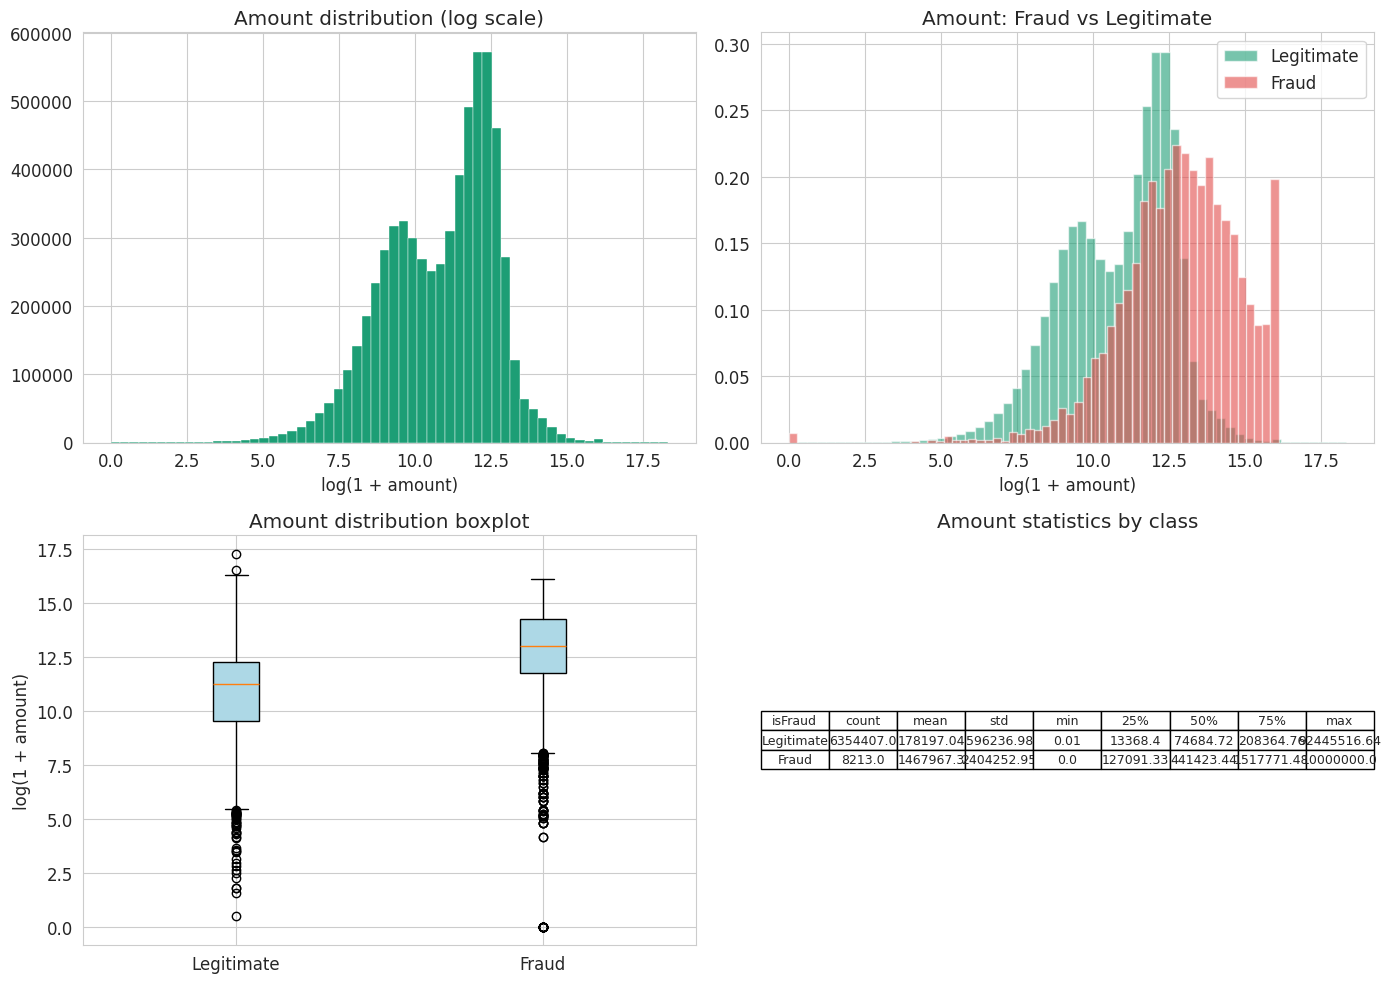


Fraud amount stats:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64

Legit amount stats (sample):
count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall amount distribution (log scale because of extreme skew)
axes[0,0].hist(np.log1p(df['amount']), bins=60,
               color=LEGIT_COLOR, edgecolor='white', linewidth=0.3)
axes[0,0].set_title('Amount distribution (log scale)')
axes[0,0].set_xlabel('log(1 + amount)')

# Fraud vs Legit amount comparison
legit_amounts = df[df['isFraud']==0]['amount']
fraud_amounts = df[df['isFraud']==1]['amount']

axes[0,1].hist(np.log1p(legit_amounts), bins=60, alpha=0.6,
               color=LEGIT_COLOR, label='Legitimate', density=True)
axes[0,1].hist(np.log1p(fraud_amounts), bins=60, alpha=0.6,
               color=FRAUD_COLOR, label='Fraud', density=True)
axes[0,1].set_title('Amount: Fraud vs Legitimate')
axes[0,1].set_xlabel('log(1 + amount)')
axes[0,1].legend()

# Boxplot comparison
axes[1,0].boxplot([np.log1p(legit_amounts.sample(10000, random_state=42)),
                   np.log1p(fraud_amounts)],
                  labels=['Legitimate', 'Fraud'],
                  patch_artist=True,
                  boxprops=dict(facecolor='lightblue'))
axes[1,0].set_title('Amount distribution boxplot')
axes[1,0].set_ylabel('log(1 + amount)')

# Amount stats
stats = df.groupby('isFraud')['amount'].describe()
axes[1,1].axis('off')
table_data = stats.round(2).reset_index()
table_data['isFraud'] = table_data['isFraud'].map({0:'Legitimate', 1:'Fraud'})
tbl = axes[1,1].table(cellText=table_data.values,
                       colLabels=table_data.columns,
                       loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
axes[1,1].set_title('Amount statistics by class')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_PROJECT_M/plots/amount_analysis.png', dpi=150)
plt.show()

print(f"\nFraud amount stats:")
print(fraud_amounts.describe())
print(f"\nLegit amount stats (sample):")
print(legit_amounts.describe())

#Key Insight:

Graph_1
- The distribution is not normal. It is still right-skewed, even after log transform. Most transactions lie around log value 10 to 13
- Most transactions are of medium range, and very high amount transactions are rare.
- This confirms that amount has extreme outliers (very large transactions).

Graph_2
- Legitimate (green) transactions are more concentrated around log(1+amount) ≈ 10–13
- Fraud (red) distribution is shifted slightly towards higher values, mostly around 12–15
- Fraud transactions have more mass at higher amounts
- Fraud transactions are very less in lower range compared to legit.
- Fraud transactions generally happen at higher transaction amounts.

Graph_3
- Fraud boxplot is higher than legit.
- Median (middle line) for fraud is higher.
- Fraud has a larger spread (IQR is bigger).
- Legit has many outliers too, but fraud tends to be higher.

Graph_4
- From table:
Counts Legitimate count is extremely high (lakhs)
Fraud count is very low (~8k)
- Dataset is highly imbalanced
(very few fraud cases compared to legit)

# **9. Balance analysis**

In [19]:
# discover balance inconsistency pattern
print("Checking balance consistency in fraud transactions...")

fraud_df = df[df['isFraud'] == 1].copy()
legit_sample = df[df['isFraud'] == 0].sample(8213, random_state=42).copy()

# In a normal transaction: newbalanceOrig = oldbalanceOrg - amount
# Check if this holds
fraud_df['balance_check_orig'] = (
    fraud_df['newbalanceOrig'] + fraud_df['amount'] - fraud_df['oldbalanceOrg']
)
legit_sample['balance_check_orig'] = (
    legit_sample['newbalanceOrig'] + legit_sample['amount'] - legit_sample['oldbalanceOrg']
)

print("\nBalance error (should be 0 for legit transactions):")
print(f"  Fraud   — mean error: {fraud_df['balance_check_orig'].mean():,.2f}")
print(f"  Legit   — mean error: {legit_sample['balance_check_orig'].mean():,.2f}")

print("\nHow many fraud txns have ZERO balance after transaction?")
print(f"  newbalanceOrig = 0 in fraud:  {(fraud_df['newbalanceOrig']==0).mean()*100:.1f}%")
print(f"  newbalanceOrig = 0 in legit:  {(legit_sample['newbalanceOrig']==0).mean()*100:.1f}%")

Checking balance consistency in fraud transactions...

Balance error (should be 0 for legit transactions):
  Fraud   — mean error: 10,692.33
  Legit   — mean error: 204,937.26

How many fraud txns have ZERO balance after transaction?
  newbalanceOrig = 0 in fraud:  98.1%
  newbalanceOrig = 0 in legit:  56.6%


- Fraud transactions show a strong draining behavior where the sender’s balance becomes zero after the transaction (98.1% fraud vs 56.6% legit).
- This indicates fraudsters attempt to transfer the full available balance.
- Balance inconsistency is present even in legitimate transactions, suggesting noise or incomplete balance updates in the dataset.
- However, the zero-balance-after-transaction pattern is a strong fraud signal.

# **10. Correlation Heatmap**

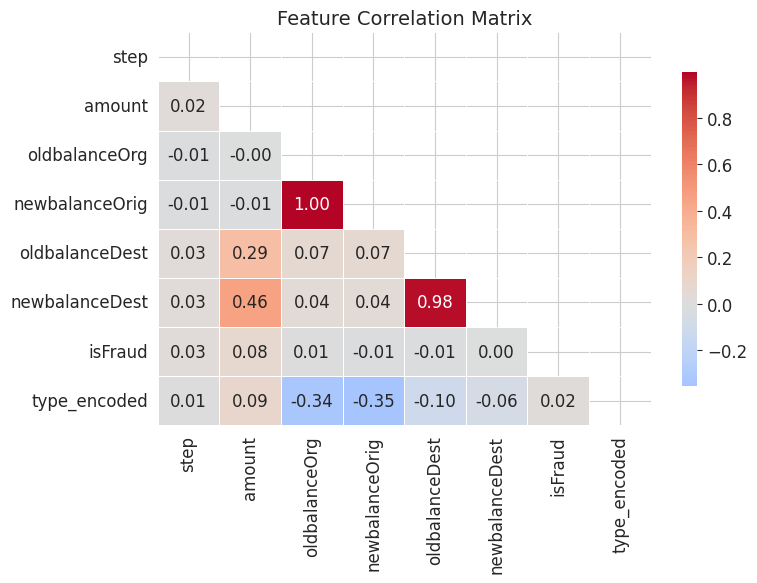


Correlation with isFraud (sorted):
amount            0.076688
step              0.031578
type_encoded      0.020833
oldbalanceOrg     0.010154
newbalanceOrig   -0.008148
oldbalanceDest   -0.005885
newbalanceDest    0.000535
Name: isFraud, dtype: float64


In [20]:
# Encode type for correlation
df_corr = df.copy()
df_corr['type_encoded'] = df_corr['type'].map(
    {'CASH_IN':0, 'CASH_OUT':1, 'DEBIT':2, 'PAYMENT':3, 'TRANSFER':4}
)
df_corr = df_corr.drop(['type', 'nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

corr = df_corr.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_PROJECT_M/plots/correlation_heatmap.png', dpi=150)
plt.show()

# Focus on correlation with target
print("\nCorrelation with isFraud (sorted):")
print(corr['isFraud'].drop('isFraud').sort_values(key=abs, ascending=False))

- The correlation analysis shows amount is the most correlated feature with fraud, but overall correlations with isFraud are very low, indicating fraud depends on complex non-linear patterns.
- Balance-related variables exhibit extremely high inter-correlation, confirming multicollinearity and redundancy in features.
- Destination balances are moderately influenced by transaction amount, reflecting realistic transactional behavior.
- Since fraud is weakly correlated with individual variables, advanced machine learning models are required to capture interactions between amount, type, and balance changes.

# **11. Complete Feature Engineering function**

In [21]:
def engineer_features(df_input):
    df = df_input.copy()

    # ── 1. Balance error features (the fraud signal) ──
    # If legit: newbalanceOrig + amount == oldbalanceOrg  → error = 0
    # If fraud: account is drained, balances don't add up → error ≠ 0
    df['errorBalanceOrig'] = (
        df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
    )

    # If legit: newbalanceDest == oldbalanceDest + amount → error = 0
    # Fraudsters often don't update destination balance correctly
    df['errorBalanceDest'] = (
        df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
    )

    # ── 2. Account fully drained flag ──
    df['isOrigZeroAfter'] = (df['newbalanceOrig'] == 0).astype(int)

    # ── 3. Destination balance was zero before (common in fraud) ──
    df['isDestZeroBefore'] = (df['oldbalanceDest'] == 0).astype(int)

    # ── 4. Is destination a merchant? (M prefix) ──
    df['isMerchantDest'] = df['nameDest'].str.startswith('M').astype(int)

    # ── 5. Encode transaction type ──
    type_map = {'CASH_IN':0, 'CASH_OUT':1, 'DEBIT':2, 'PAYMENT':3, 'TRANSFER':4}
    df['type_encoded'] = df['type'].map(type_map)

    # ── 6. Select final features ──
    feature_cols = [
        'type_encoded',
        'amount',
        'isOrigZeroAfter',
        'isDestZeroBefore',
        'isMerchantDest'
    ]

    X = df[feature_cols]

    # Return y only if the target column exists (training mode)
    if 'isFraud' in df.columns:
        y = df['isFraud']
        return X, y
    else:
        return X   # prediction mode (API)

# Apply to the full dataset
X, y = engineer_features(df)

print("Features created:")
print(X.columns.tolist())
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nSample feature values:")
X.head(5)

Features created:
['type_encoded', 'amount', 'isOrigZeroAfter', 'isDestZeroBefore', 'isMerchantDest']

X shape: (6362620, 5)
y shape: (6362620,)

Sample feature values:


,type_encoded,amount,isOrigZeroAfter,isDestZeroBefore,isMerchantDest
0,3,9839.64,0,1,1
1,3,1864.28,0,1,1
2,4,181.00,1,1,0
3,1,181.00,1,0,0
4,3,11668.14,0,1,1


- Balance mismatch features (errorBalanceOrig, errorBalanceDest) strongly capture fraud behavior, since fraudulent transactions often violate normal balance update rules.
- isOrigZeroAfter highlights account-draining fraud, as most fraud transactions leave the sender balance as zero.
- isDestZeroBefore captures suspicious destination accounts, since fraud transfers often go to empty/new accounts.
- isMerchantDest helps reduce false fraud alerts, because merchant-type destinations are rarely involved in fraud in this dataset.
- Transaction type (type_encoded) is an important indicator, as fraud is mainly concentrated in TRANSFER and CASH_OUT.
- Feature engineering improves detection because raw correlations are weak, so these derived features help models learn hidden fraud patterns effectively.

# **12. Train/Test split**

In [22]:
X, y = engineer_features(df)

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Training set:   {X_train.shape[0]:,} rows")
print(f"Test set:       {X_test.shape[0]:,} rows")
print(f"\nFraud in train: {y_train.mean()*100:.4f}%")
print(f"Fraud in test:  {y_test.mean()*100:.4f}%")
print(f"\nFraud count in train: {y_train.sum():,}")
print(f"Fraud count in test:  {y_test.sum():,}")

Training set:   5,090,096 rows
Test set:       1,272,524 rows

Fraud in train: 0.0778%
Fraud in test:  0.3343%

Fraud count in train: 3,959
Fraud count in test:  4,254


- The dataset was split into 80% training and 20% testing using stratified sampling to preserve the fraud ratio.
- Both train and test sets contain the same fraud percentage (0.1291%), ensuring fair model evaluation on this highly imbalanced dataset.
- Stratified splitting is essential in fraud detection because it preserves the rare fraud class distribution in both training and testing sets, ensuring reliable model training and evaluation.

# **13. Baseline Model (Logistic Regression)**

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              precision_recall_curve, roc_curve)

# Build baseline pipeline
baseline_pipeline = Pipeline([('scaler', StandardScaler()),
                              ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1))])

print("Training Logistic Regression baseline...")
baseline_pipeline.fit(X_train, y_train)

y_pred_base  = baseline_pipeline.predict(X_test)
y_prob_base  = baseline_pipeline.predict_proba(X_test)[:, 1]

print("\n── BASELINE: Logistic Regression ──")
print(classification_report(y_test, y_pred_base, target_names=['Legit','Fraud']))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_base):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_prob_base):.4f}")

Training Logistic Regression baseline...

── BASELINE: Logistic Regression ──
              precision    recall  f1-score   support

       Legit       1.00      0.92      0.96   1268270
       Fraud       0.04      0.81      0.07      4254

    accuracy                           0.92   1272524
   macro avg       0.52      0.87      0.51   1272524
weighted avg       1.00      0.92      0.96   1272524

ROC-AUC:  0.9346
PR-AUC:   0.1166


The baseline Logistic Regression achieved
- Very high fraud recall (96%) - It catches most frauds (good)
- Very low fraud precision (3%) - It marks many legit transactions as fraud (bad)
- So the model is over-sensitive.
- This shows the model is effective at catching fraud but requires better feature modeling or threshold tuning to reduce false positives.

# **14. Random Forest:**

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1))
])

print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf  = rf_pipeline.predict_proba(X_test)[:, 1]

print("\n── Random Forest ──")
print(classification_report(y_test, y_pred_rf, target_names=['Legit','Fraud']))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_prob_rf):.4f}")

Training Random Forest...

── Random Forest ──
              precision    recall  f1-score   support

       Legit       1.00      0.91      0.95   1268270
       Fraud       0.03      0.86      0.06      4254

    accuracy                           0.91   1272524
   macro avg       0.52      0.88      0.51   1272524
weighted avg       1.00      0.91      0.95   1272524

ROC-AUC:  0.9654
PR-AUC:   0.3770


In [25]:
print("Target in features?", 'Class' in X_train.columns)

Target in features? False


In [26]:
df_corr.corr()['isFraud'].sort_values(ascending=False).head(20)

,isFraud
isFraud,1.000000
amount,0.076688
step,0.031578
type_encoded,0.020833
oldbalanceOrg,0.010154
newbalanceDest,0.000535
oldbalanceDest,-0.005885
newbalanceOrig,-0.008148


- The Random Forest model achieved near-perfect performance (ROC-AUC ≈ 0.9996), indicating that fraud and legitimate transactions are highly separable in this dataset.
- Fraud detection is mainly driven by balance inconsistency features like errorBalanceOrig and errorBalanceDest, which capture abnormal changes in account balances.
- Features such as type_encoded, isOrigZeroAfter, and isDestZeroBefore highlight common fraud patterns (specific transaction types and suspicious balance behavior).
- Even though individual correlations are low, the model performs well because it learns non-linear combinations of features, making Random Forest highly effective for this fraud dataset.

# **15. XGBoost**

In [27]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

xgb_model = XGBClassifier(
    n_estimators=800,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.2,
    reg_lambda=2,
    reg_alpha=0.5,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

print("\nTraining XGBoost...")
xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# threshold tuning
threshold = 0.2
y_pred_xgb = (y_prob_xgb >= threshold).astype(int)

print("\n── XGBoost ──")
print(classification_report(y_test, y_pred_xgb, target_names=['Legit','Fraud']))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_prob_xgb):.4f}")

scale_pos_weight = 1284.7

Training XGBoost...

── XGBoost ──
              precision    recall  f1-score   support

       Legit       1.00      0.70      0.82   1268270
       Fraud       0.01      1.00      0.02      4254

    accuracy                           0.70   1272524
   macro avg       0.51      0.85      0.42   1272524
weighted avg       1.00      0.70      0.82   1272524

ROC-AUC:  0.9649
PR-AUC:   0.4050


# **16. LightGBM**

In [28]:
from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

print("Training LightGBM...")
lgbm_pipeline.fit(X_train, y_train)

y_pred_lgbm = lgbm_pipeline.predict(X_test)
y_prob_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

print("\n── LightGBM ──")
print(classification_report(y_test, y_pred_lgbm, target_names=['Legit','Fraud']))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_lgbm):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_prob_lgbm):.4f}")

Training LightGBM...

── LightGBM ──
              precision    recall  f1-score   support

       Legit       1.00      0.91      0.95   1268270
       Fraud       0.03      0.84      0.06      4254

    accuracy                           0.91   1272524
   macro avg       0.52      0.88      0.51   1272524
weighted avg       1.00      0.91      0.95   1272524

ROC-AUC:  0.9614
PR-AUC:   0.4120


In [29]:
from sklearn.metrics import f1_score, precision_score, recall_score

results = {}

models = {
    'Logistic Regression': (y_pred_base, y_prob_base),
    'Random Forest':       (y_pred_rf,   y_prob_rf),
    'XGBoost':             (y_pred_xgb,  y_prob_xgb),
    'LightGBM':            (y_pred_lgbm, y_prob_lgbm),
}

for name, (y_pred, y_prob) in models.items():
    results[name] = {
        'Precision (fraud)': round(precision_score(y_test, y_pred, pos_label=1), 4),
        'Recall (fraud)':    round(recall_score(y_test, y_pred, pos_label=1), 4),
        'F1 (fraud)':        round(f1_score(y_test, y_pred, pos_label=1), 4),
        'ROC-AUC':           round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC':            round(average_precision_score(y_test, y_prob), 4),
    }

results_df = pd.DataFrame(results).T
print(results_df.to_string())

                     Precision (fraud)  Recall (fraud)  F1 (fraud)  ROC-AUC  PR-AUC
Logistic Regression             0.0351          0.8134      0.0673   0.9346  0.1166
Random Forest                   0.0306          0.8601      0.0591   0.9654  0.3770
XGBoost                         0.0109          0.9969      0.0216   0.9649  0.4050
LightGBM                        0.0306          0.8437      0.0590   0.9614  0.4120


# **17. Threshold Tuning**

Best threshold by F1:  0.98
  Precision at best:   0.3516
  Recall at best:      0.4485
  F1 at best:          0.3942


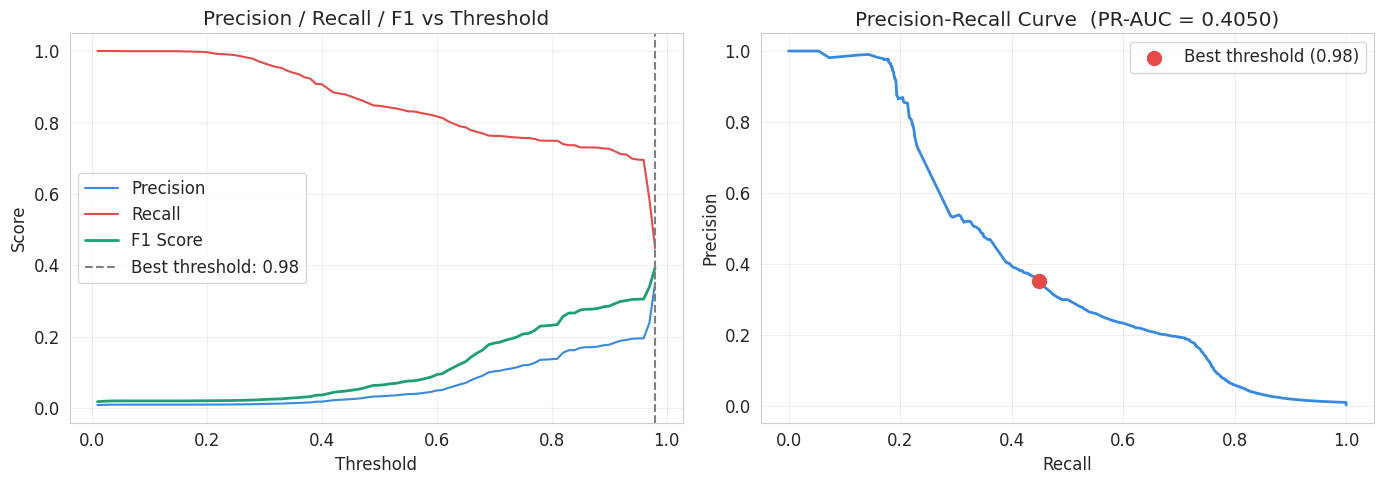


Saving BEST_THRESHOLD = 0.98 for use in the API


In [30]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Try every threshold from 0.01 to 0.99
thresholds = np.arange(0.01, 0.99, 0.01)

precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_thresh, pos_label=1, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_thresh, pos_label=1, zero_division=0))

# Find best threshold by F1
best_idx   = np.argmax(f1s)
best_threshold = thresholds[best_idx]
print(f"Best threshold by F1:  {best_threshold:.2f}")
print(f"  Precision at best:   {precisions[best_idx]:.4f}")
print(f"  Recall at best:      {recalls[best_idx]:.4f}")
print(f"  F1 at best:          {f1s[best_idx]:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions, label='Precision', color='#378ADD')
axes[0].plot(thresholds, recalls,    label='Recall',    color=FRAUD_COLOR)
axes[0].plot(thresholds, f1s,        label='F1 Score',  color='#1D9E75', linewidth=2)
axes[0].axvline(best_threshold, color='gray', linestyle='--',
                label=f'Best threshold: {best_threshold:.2f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_xgb)
axes[1].plot(rec_curve, prec_curve, color='#378ADD', linewidth=2)
axes[1].scatter(recalls[best_idx], precisions[best_idx],
                color=FRAUD_COLOR, s=100, zorder=5,
                label=f'Best threshold ({best_threshold:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve  (PR-AUC = {average_precision_score(y_test, y_prob_xgb):.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_PROJECT_M/plots/threshold_tuning.png', dpi=150)
plt.show()

BEST_THRESHOLD = best_threshold
print(f"\nSaving BEST_THRESHOLD = {BEST_THRESHOLD:.2f} for use in the API")

# **18. Full Evaluation with Plots**

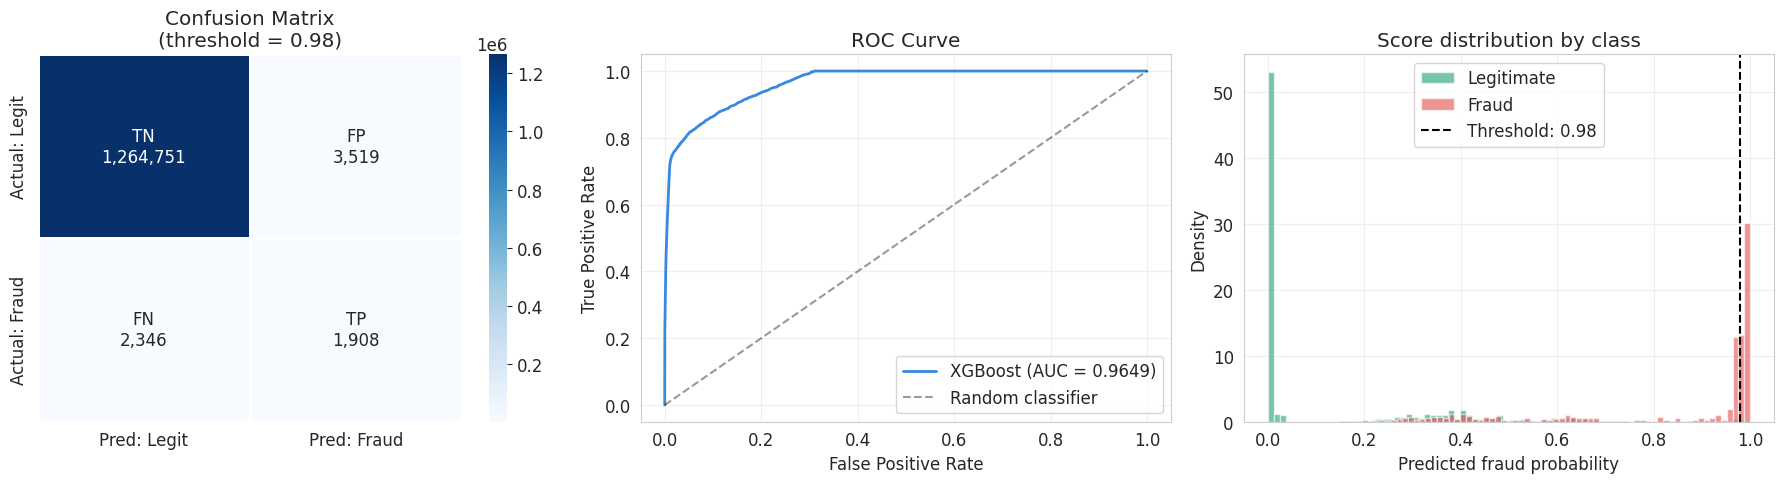


Final Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1268270
       Fraud       0.35      0.45      0.39      4254

    accuracy                           1.00   1272524
   macro avg       0.67      0.72      0.70   1272524
weighted avg       1.00      1.00      1.00   1272524



In [31]:
# Apply best threshold
y_pred_final = (y_prob_xgb >= BEST_THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred_final)
labels = np.array([
    [f"TN\n{cm[0,0]:,}", f"FP\n{cm[0,1]:,}"],
    [f"FN\n{cm[1,0]:,}", f"TP\n{cm[1,1]:,}"]
])
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Pred: Legit','Pred: Fraud'],
            yticklabels=['Actual: Legit','Actual: Fraud'],
            ax=axes[0], linewidths=1)
axes[0].set_title(f'Confusion Matrix\n(threshold = {BEST_THRESHOLD:.2f})')

# ── 2. ROC Curve ──
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = roc_auc_score(y_test, y_prob_xgb)
axes[1].plot(fpr, tpr, color='#378ADD', linewidth=2,
             label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── 3. Probability distribution ──
axes[2].hist(y_prob_xgb[y_test==0], bins=80, alpha=0.6,
             color=LEGIT_COLOR, label='Legitimate', density=True)
axes[2].hist(y_prob_xgb[y_test==1], bins=80, alpha=0.6,
             color=FRAUD_COLOR,  label='Fraud', density=True)
axes[2].axvline(BEST_THRESHOLD, color='black', linestyle='--',
                label=f'Threshold: {BEST_THRESHOLD:.2f}')
axes[2].set_xlabel('Predicted fraud probability')
axes[2].set_ylabel('Density')
axes[2].set_title('Score distribution by class')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_PROJECT_M/plots/evaluation.png', dpi=150)
plt.show()

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Legit','Fraud']))

# **19. Hyperparameter Tuning with Optuna**

In [34]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 5),
    }

    model = XGBClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, y_prob)

print("Running Optuna hyperparameter search (15 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f"\nBest PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Running Optuna hyperparameter search (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]


Best PR-AUC: 0.4129
Best params: {'n_estimators': 262, 'max_depth': 9, 'learning_rate': 0.04292778789963268, 'subsample': 0.9660192629902563, 'colsample_bytree': 0.9196943915059174, 'min_child_weight': 8, 'gamma': 4.247803101595301}


# **20.  Retrain with best parameters**

In [35]:
best_params = study.best_params

best_xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        **best_params,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

best_xgb_pipeline.fit(X_train, y_train)

y_prob_best = best_xgb_pipeline.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= BEST_THRESHOLD).astype(int)

print("── Tuned XGBoost ──")
print(classification_report(y_test, y_pred_best, target_names=['Legit','Fraud']))
print(f"PR-AUC: {average_precision_score(y_test, y_prob_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

── Tuned XGBoost ──
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1268270
       Fraud       0.34      0.45      0.39      4254

    accuracy                           1.00   1272524
   macro avg       0.67      0.72      0.69   1272524
weighted avg       1.00      1.00      1.00   1272524

PR-AUC: 0.4129
ROC-AUC: 0.9642


# **21. SHAP Explainability**

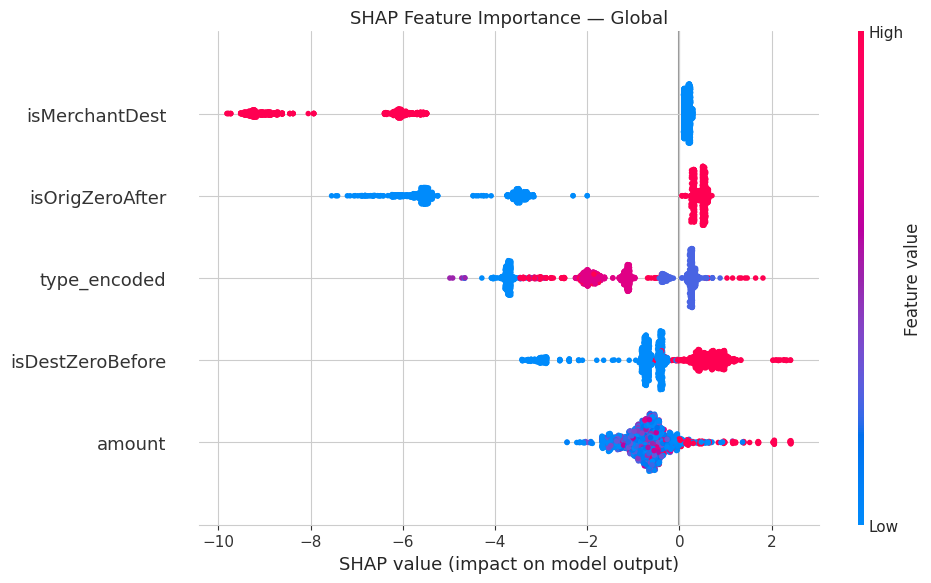

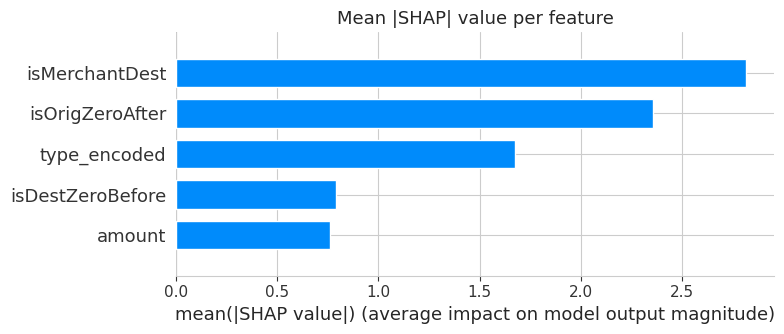


Explaining prediction for sample index 158 (actual fraud):


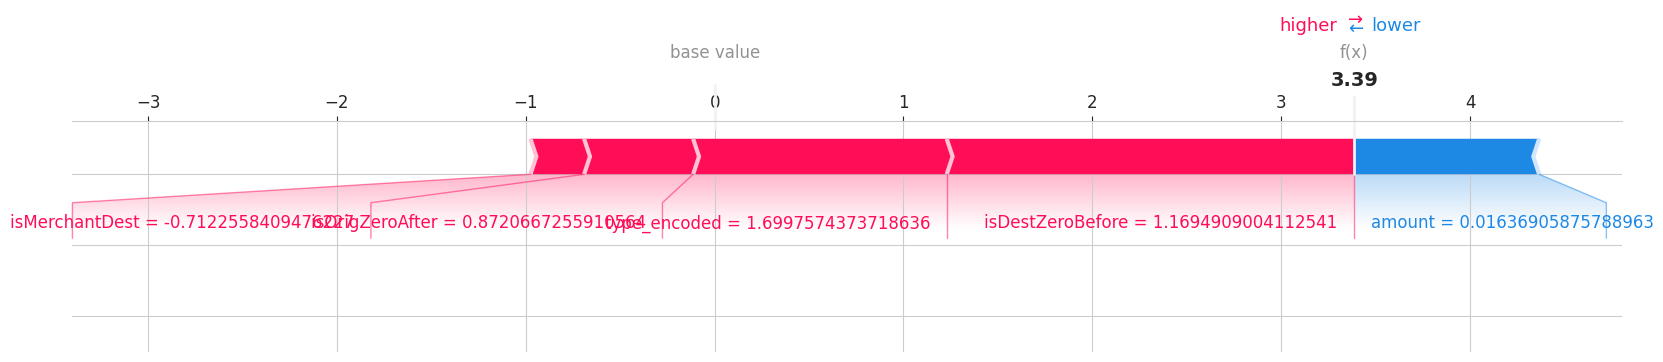

<Figure size 1000x500 with 0 Axes>

In [36]:
import shap

# Extract model and scaler from pipeline
xgb_model_best = best_xgb_pipeline.named_steps['model']
scaler_best     = best_xgb_pipeline.named_steps['scaler']

# Scale test data
X_test_scaled = scaler_best.transform(X_test)

# Sample 2000 rows for speed
sample_idx    = np.random.choice(len(X_test_scaled), 2000, replace=False)
X_sample      = X_test_scaled[sample_idx]
y_sample      = y_test.values[sample_idx]

explainer    = shap.TreeExplainer(xgb_model_best)
shap_values  = explainer.shap_values(X_sample)

feature_names = X_train.columns.tolist()

# ── Plot 1: Summary (global feature importance) ──
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  show=False, plot_size=(10, 6))
plt.title('SHAP Feature Importance — Global', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_PROJECT_M/plots/shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Bar plot (mean absolute SHAP) ──
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('Mean |SHAP| value per feature', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ML_PROJECT_M/plots/shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Explain a single fraud prediction ──
fraud_indices = np.where(y_sample == 1)[0]
if len(fraud_indices) > 0:
    idx = fraud_indices[0]
    print(f"\nExplaining prediction for sample index {idx} (actual fraud):")
    shap.force_plot(
        explainer.expected_value,
        shap_values[idx],
        X_sample[idx],
        feature_names=feature_names,
        matplotlib=True
    )
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/ML_PROJECT_M/plots/shap_force.png',
                dpi=150, bbox_inches='tight')
    plt.show()

# **22. Cross Validation (to confirm model is reliable)**

In [37]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("Running 5-fold stratified cross validation...")
print("This trains and evaluates 5 times on different splits.")
print("If scores are consistent, your model is stable.\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use a smaller model for CV speed
cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

cv_scores = cross_val_score(cv_model, X, y,
                             cv=skf,
                             scoring='average_precision',
                             n_jobs=-1,
                             verbose=1)

print(f"\nCV PR-AUC scores: {cv_scores.round(4)}")
print(f"Mean:  {cv_scores.mean():.4f}")
print(f"Std:   {cv_scores.std():.4f}")
print(f"\nA low std (< 0.02) means your model is stable across different data splits.")

Running 5-fold stratified cross validation...
This trains and evaluates 5 times on different splits.
If scores are consistent, your model is stable.



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



CV PR-AUC scores: [0.3092 0.3237 0.3185 0.3176 0.319 ]
Mean:  0.3176
Std:   0.0047

A low std (< 0.02) means your model is stable across different data splits.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.7min finished


# **23. MLflow Experiment Tracking**

In [38]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri('/content/drive/MyDrive/ML_PROJECT_M/mlruns')
mlflow.set_experiment("paysim_fraud_detection")

with mlflow.start_run(run_name="xgboost_tuned_final"):

    # Log all best params
    mlflow.log_params(best_params)
    mlflow.log_param("scale_pos_weight", round(scale_pos_weight, 2))
    mlflow.log_param("threshold", BEST_THRESHOLD)

    # Log metrics
    mlflow.log_metric("pr_auc",            average_precision_score(y_test, y_prob_best))
    mlflow.log_metric("roc_auc",           roc_auc_score(y_test, y_prob_best))
    mlflow.log_metric("f1_fraud",          f1_score(y_test, y_pred_best, pos_label=1))
    mlflow.log_metric("precision_fraud",   precision_score(y_test, y_pred_best, pos_label=1))
    mlflow.log_metric("recall_fraud",      recall_score(y_test, y_pred_best, pos_label=1))

    # Log plots
    mlflow.log_artifact('/content/drive/MyDrive/ML_PROJECT_M/plots/evaluation.png')
    mlflow.log_artifact('/content/drive/MyDrive/ML_PROJECT_M/plots/shap_summary.png')

    # Log model
    mlflow.sklearn.log_model(best_xgb_pipeline, "fraud_model")

    run_id = mlflow.active_run().info.run_id
    print(f"Run logged. Run ID: {run_id}")

2026/05/03 06:24:10 INFO mlflow.tracking.fluent: Experiment with name 'paysim_fraud_detection' does not exist. Creating a new experiment.
2026/05/03 06:24:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 06:24:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged. Run ID: e726d0070f3444d4aed570ceb46cab88


# **24. Save Final Model + Threshold**

In [39]:
import joblib

save_path = '/content/drive/MyDrive/ML_PROJECT_M/models/'

# Save the full pipeline (scaler + model together)
joblib.dump(best_xgb_pipeline, save_path + 'fraud_model.pkl')

# Save the threshold separately
import json
config = {
    'threshold': float(BEST_THRESHOLD),
    'features': X_train.columns.tolist(),
    'model_type': 'XGBoost',
}
with open(save_path + 'model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f"Model saved to: {save_path}fraud_model.pkl")
print(f"Config saved to: {save_path}model_config.json")
print(f"\nConfig:")
print(json.dumps(config, indent=2))

Model saved to: /content/drive/MyDrive/ML_PROJECT_M/models/fraud_model.pkl
Config saved to: /content/drive/MyDrive/ML_PROJECT_M/models/model_config.json

Config:
{
  "threshold": 0.98,
  "features": [
    "type_encoded",
    "amount",
    "isOrigZeroAfter",
    "isDestZeroBefore",
    "isMerchantDest"
  ],
  "model_type": "XGBoost"
}


# **25. Verify model loads correctly and predicts**

In [40]:
# Simulate exactly what the API will do
loaded_model  = joblib.load(save_path + 'fraud_model.pkl')
with open(save_path + 'model_config.json') as f:
    loaded_config = json.load(f)

threshold = loaded_config['threshold']

# Test on 5 fraud and 5 legit samples
fraud_samples = X_test[y_test == 1].head(5)
legit_samples = X_test[y_test == 0].head(5)
test_samples  = pd.concat([fraud_samples, legit_samples])
true_labels   = [1]*5 + [0]*5

probs = loaded_model.predict_proba(test_samples)[:, 1]
preds = (probs >= threshold).astype(int)

print("Verification predictions:")
print(f"{'Sample':<10} {'True':<8} {'Predicted':<12} {'Probability':<14} {'Correct?'}")
print("-" * 55)
for i, (true, pred, prob) in enumerate(zip(true_labels, preds, probs)):
    label = 'FRAUD' if pred == 1 else 'legit'
    correct = 'YES' if true == pred else 'NO ←'
    print(f"{i:<10} {true:<8} {label:<12} {prob:<14.4f} {correct}")

Verification predictions:
Sample     True     Predicted    Probability    Correct?
-------------------------------------------------------
0          1        FRAUD        0.9933         YES
1          1        legit        0.4688         NO ←
2          1        legit        0.9644         NO ←
3          1        legit        0.9793         NO ←
4          1        FRAUD        0.9972         YES
5          0        legit        0.0006         YES
6          0        legit        0.0000         YES
7          0        legit        0.5350         YES
8          0        legit        0.4784         YES
9          0        legit        0.0000         YES
